**Approaches to modelling thrust**
- Regression approach: Fitting regression models to thrust, velocity, or motion curves to get relevant coefficients.
- Averaged approach: Take a weighted mean of all thrust curves to obtain the final curve.

**Initial Regression Approach**

The force acting on the cart can be reconstructed by fitting a regression model over position data. The end behavior of the thrust should be exponentially decaying. The decaying model works well after peak thrust has been reached, but cannot capture the behavior of the canister before reaching peak thrust.

$$
\begin{align*}
x(t) &= \alpha t+\beta+\gamma e^{-\kappa t} \\
\dot{x}(t) &= \alpha-\gamma \kappa e^{-\kappa t} \\
\ddot{x}(t) &= \gamma \kappa^2 e^{-\kappa t} = \frac{F_{thrust}(t)}{m_{test}}
\end{align*}
$$

**Revised Approach 1**

After analyzing Hydron's data, an empirical revision to the model has been applied to better capture the initial behavior.

$$
\ddot{x}(t) = \exp(\kappa t^{0.02}+ \alpha t^2 + \beta t + \gamma)
$$

This model is more versatile, since it can be applied directly to thrust data.

**Revised Approach 2**

To ensure the model has a finite slope at t=0, instead of multiplying an exponentiated quadratic by $\exp(\alpha t^{0.02})$, it is multiplied by a function $\phi(t)$ that converges to 1 quickly as t->infinity but has a finite slope at t=0. An exponential $1-e^{-\kappa t}$ can be used for $\phi (t)$.

This yields the equation

$$
\begin{align*}
\ddot{x}(t) &= \phi(t)\exp(\alpha t^2 + \beta t + \gamma ) \\
& = (1-e^{-\kappa t})\exp(\alpha t^2 + \beta t + \gamma )
\end{align*}
$$

**Pinnacle Data:**

The following data is reconstructed from the graph shown in Team Pinnacle's portfolio.

```
time = [0.,0.02,0.04,0.1,0.44]
thrust = [0.,18.5,12.,7.7,0.]
```





[ 1.12658275e+03 -7.15393211e-28 -1.18077507e+01  3.09548426e+00]


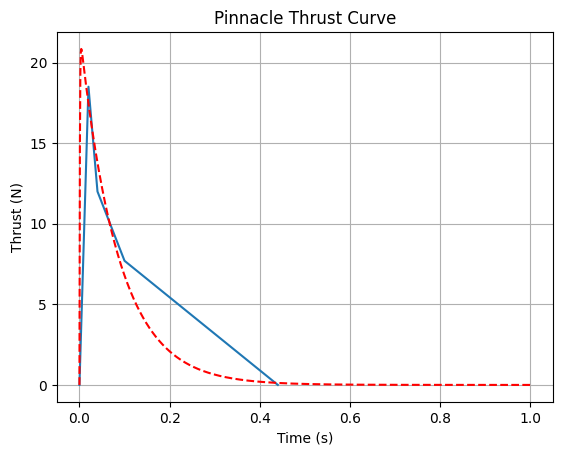

In [16]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

time = [0.,0.02,0.04,0.1,0.44]
thrust = [0.,18.5,12.,7.7,0.]


def func(t,k,a,b,c):
  return (1-np.exp(-k*t))*np.exp(a*t**2+b*t+c)

popt, pcov = curve_fit(func, time, thrust, bounds = (-np.inf,[np.inf,0.,np.inf,np.inf]))
print(popt)

plot_time = np.linspace(0.,1.,1000)

plt.plot(time, thrust)
plt.plot(plot_time, func(plot_time, *popt), 'r--')
plt.xlabel("Time (s)")
plt.ylabel("Thrust (N)")
plt.title("Pinnacle Thrust Curve")
plt.grid(True)
plt.show()

**Hydron Data**



**Thrust Experiment V1**

A good metric for determining the validity of thrust data in force tests is the impulse, since it is directly related to the change in momentum, which is a known constant. However, since the mass of the cart changes, the impulse is not exactly related to the momentum change.
$$
\begin{align*}
\int dp &= \int vdm + \int F dt \\
\Delta p&=\int_0^{t_f} v\dot{m} \ dt + J
\end{align*}
$$
If $\dot{m}$ is constant,
$$
\Delta p = \dot{m}\Delta x + J \\
J= \Delta p- \underbrace{\dot{m}\Delta x}_{\text{correction}}
$$
If we estimate the mass flux to be 8 grams in 0.3 seconds (the cart travels at most 50 cm in 0.3 seconds), the correction term turns out to be approximately 0.013 Ns. Therefore, we expect the impulse to underpredict the change in momentum by at most 0.02 Ns.

**Thrust Experiment V2**

   Time (relative)    Trial 2    Trial 3    Trial 4    Trial 5    Trial 6  \
0             0.00  11.993937  11.926452  12.018477  11.220926   5.460155   
1             0.02  11.993937   8.319068   5.141135  11.220926  11.895777   
2             0.04  11.036876   8.190233   8.227043  11.220926   8.865084   
3             0.06   6.674887  11.926452   7.791458  10.184110   7.852808   
4             0.08   5.987766   9.417234   7.202497   8.466308   6.901882   

     Trial 8  
0  11.472461  
1  11.472461  
2  11.472461  
3  11.472461  
4   3.269958  
[117.38279144  -2.95203651  -7.14373122   2.73782617]
1.8464821855488531


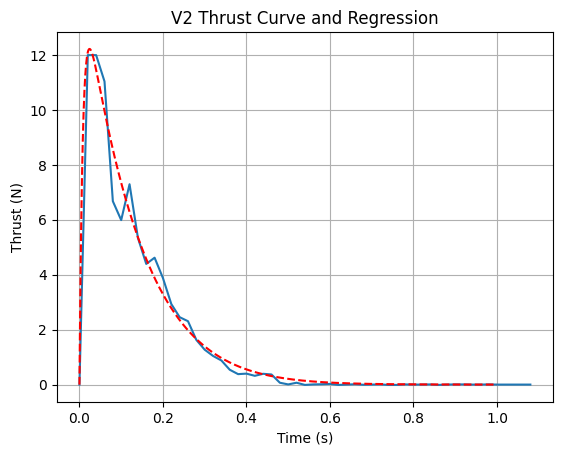

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import scipy.integrate as integrate


df = pd.read_csv(r"Thrust data\thrust_experiment_v2.csv")

time = df["Time (relative)"][:54]
thrust_data = df.iloc[:54, 12:18]

corrected_data = pd.concat([time,thrust_data], axis=1)

for col in corrected_data.columns:
    corrected_data[col] = pd.to_numeric(corrected_data[col], errors='coerce')

print(corrected_data.head())

thrust = corrected_data.iloc[:,1].tolist()
thrust.insert(0,0.)
time = [i+0.02 for i in time]
time.insert(0,0.)

def func(t,k,a,b,c):
  return (1-np.exp(-k*t))*np.exp(a*t**2+b*t+c)

popt, pcov = curve_fit(func, time, thrust, bounds = (-np.inf,[np.inf,0.,np.inf,np.inf]))
print(popt)

plot_time = np.linspace(0.,1.,1000)

print(integrate.simpson(func(plot_time, *popt), plot_time))

plt.plot(time, thrust)
plt.plot(plot_time, func(plot_time, *popt), 'r--')
plt.xlabel("Time (s)")
plt.ylabel("Thrust (N)")
plt.title("V2 Thrust Curve and Regression")
plt.grid(True)
plt.show()


**Thrust Experiment V3**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"Thrust data\thrust_experiment_v3.csv")

time = df["Time (s)"][:251]
thrust_data = df.iloc[:251, 1:]

data_v3 = pd.concat([time,thrust_data], axis=1)

for col in data_v3.columns:
    data_v3[col] = abs(pd.to_numeric(data_v3[col], errors='coerce'))

print(data_v3)

plt.plot(time, data_v3.iloc[:,1:])
plt.show()

**Dynamics Cart Experiment**






Determining the impulse metric for distinguishing validity of data

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

test_mass = 0.561718 #empty

df = pd.read_csv(r"Thrust data\dynamics_cart_thrust_experiment.csv")

time = df["reading"][:50]
thrust_data = df.iloc[:50, 6:]

data = df.iloc[:50, 4:10]

for col in data.columns:
    data[col] = abs(pd.to_numeric(data[col], errors='coerce'))

print(data)

def func(t,a,k,b,m):
  return m*t+a*np.exp(-k*t)+b

slopes = []

for i in range(5):
  fit_data = data.iloc[:,i+1]
  fit_data = [x for x in fit_data if not np.isnan(x)]
  popt, pcov = curve_fit(func, time[:len(fit_data)], fit_data, bounds = ([0.,0.,-np.inf,0.],[np.inf,np.inf,np.inf,np.inf]))
  slopes.append(popt[3])

print(slopes)
print(f'Final velocity (cm/s)= {slopes}')
avg_impulse = test_mass*np.mean(slopes)*0.01
print(f'Impulse (N*s) = {avg_impulse}')
print(f'Standard Error = {0.01*test_mass*np.std(slopes)/np.sqrt(5)}')

# plot_time = np.linspace(0.,1.,1000)

# plt.plot(time, data["Tape 5"])
# plt.plot(plot_time, func(plot_time, *popt), 'r--')
# plt.xlabel("Time (s)")
# plt.ylabel("Distance (cm)")
# #plt.title("Thrust experime")
# plt.grid(True)
# plt.show()

     reading  Tape 1 (cm)  Tape 2 (cm)  Tape 3  Tape 4  Tape 5
0   0.000000         0.00        0.000    0.00    0.00    0.00
1   0.016667         0.30        0.650    0.20    0.15    0.25
2   0.033333         0.50        1.700    0.50    0.70    0.50
3   0.050000         0.70        3.300    0.95    1.70    1.35
4   0.066667         1.10        5.350    1.35    2.90    2.65
5   0.083333         1.30        7.850    2.45    4.90    4.45
6   0.100000         1.60       10.800    4.10    6.95    7.10
7   0.116667         1.90       14.200    5.80    9.85   10.00
8   0.133333         2.55       17.850    8.10   12.60   13.10
9   0.150000         3.30       21.800   10.30   15.65   16.35
10  0.166667         4.25       26.150   12.65   18.65   19.15
11  0.183333         5.35       30.500   16.50   21.80   23.00
12  0.200000         7.20       35.200   22.00   24.80   26.10
13  0.216667         9.70       40.000   25.15   27.90   30.10
14  0.233333        12.60       44.850   29.30   32.70 

Max speed is less than 20 m/s, (more like 18 m/s) forgot why (might be canister temperature)
